# Data Merging

In [5]:
import pandas as pd

met_1k_api_df = pd.read_csv("data/processed/met_1k_api_test.csv")
met_objects_df = pd.read_csv("data/raw/MetObjects.txt")

/var/folders/cm/mn8_9bt54zzgsk6vsch81r8w0000gn/T/ipykernel_8584/416894730.py:4: DtypeWarning: Columns (5,7,10,11,12,13,14,34,35,36,37,38,39,40,41,42,43,44,45,46) have mixed types. Specify dtype option on import or set low_memory=False.
  met_objects_df = pd.read_csv("data/raw/MetObjects.txt")


In [14]:
import pandas as pd

def remove_spaces_lower_first(x):
    if pd.isna(x) or not isinstance(x, str):
        return x
    t = x.replace(" ", "")
    if not t:
        return t
    return t[0].lower() + t[1:]

met_objects_df.columns = [
    remove_spaces_lower_first(c) if isinstance(c, str) else c
    for c in met_objects_df.columns
]

met_objects_df.columns, met_1k_api_df.columns

(Index(['objectNumber', 'isHighlight', 'isTimelineWork', 'isPublicDomain',
        'objectID', 'galleryNumber', 'department', 'accessionYear',
        'objectName', 'title', 'culture', 'period', 'dynasty', 'reign',
        'portfolio', 'constituentID', 'artistRole', 'artistPrefix',
        'artistDisplayName', 'artistDisplayBio', 'artistSuffix',
        'artistAlphaSort', 'artistNationality', 'artistBeginDate',
        'artistEndDate', 'artistGender', 'artistULANURL', 'artistWikidataURL',
        'objectDate', 'objectBeginDate', 'objectEndDate', 'medium',
        'dimensions', 'creditLine', 'geographyType', 'city', 'state', 'county',
        'country', 'region', 'subregion', 'locale', 'locus', 'excavation',
        'river', 'classification', 'rightsandReproduction', 'linkResource',
        'objectWikidataURL', 'metadataDate', 'repository', 'tags', 'tagsAATURL',
        'tagsWikidataURL'],
       dtype='object'),
 Index(['GalleryNumber', 'accessionNumber', 'accessionYear', 'additionalIm

In [15]:
key = "objectID"
a = met_1k_api_df.copy()
b = met_objects_df.copy()
a[key] = a[key].astype(int)
b[key] = b[key].astype(int)

# Only cols not in API data
extra = [c for c in b.columns if c not in a.columns and c != key]
joined = a.merge(b[[key] + extra], on=key, how="left")

In [17]:
joined.columns

Index(['GalleryNumber', 'accessionNumber', 'accessionYear', 'additionalImages',
       'artistAlphaSort', 'artistBeginDate', 'artistDisplayBio',
       'artistDisplayName', 'artistEndDate', 'artistGender',
       'artistNationality', 'artistPrefix', 'artistRole', 'artistSuffix',
       'artistULAN_URL', 'artistWikidata_URL', 'city', 'classification',
       'constituents', 'country', 'county', 'creditLine', 'culture',
       'department', 'dimensions', 'dynasty', 'excavation', 'geographyType',
       'isHighlight', 'isPublicDomain', 'isTimelineWork', 'linkResource',
       'locale', 'locus', 'measurements', 'medium', 'metadataDate',
       'objectBeginDate', 'objectDate', 'objectEndDate', 'objectID',
       'objectName', 'objectURL', 'objectWikidata_URL', 'period', 'portfolio',
       'primaryImage', 'primaryImageSmall', 'region', 'reign', 'repository',
       'rightsAndReproduction', 'river', 'state', 'subregion', 'tags', 'title',
       'objectNumber', 'galleryNumber', 'constituentID

# Text Embeddings

In [22]:
import sys
from pathlib import Path

import pandas as pd

sys.path.insert(0, str(Path("src").resolve()))
from embed_prep import build_embedding_text

EMBED_FIELDS = [
    "title",
    "objectName",
    "department",
    "classification",
    "culture",
    "period",
    "dynasty",
    "reign",
    "portfolio",
    "medium",
    "objectDate",
    "objectBeginDate",
    "objectEndDate",
    "artistDisplayName",
    "artistDisplayBio",
    "artistRole",
    "artistPrefix",
    "artistNationality",
    "artistAlphaSort",
    "creditLine",
    "dimensions",
    "geographyType",
    "city",
    "state",
    "county",
    "country",
    "region",
    "subregion",
    "locale",
    "locus",
    "excavation",
    "river",
    "repository",
    # "accessionNumber",
    # "objectNumber",
    "rightsAndReproduction",
]

joined["embed_text"] = joined.apply(
    lambda r: build_embedding_text(
        r,
        fields=EMBED_FIELDS,
        include_tags=True,
        include_constituents=True,
    ),
    axis=1,
)

In [24]:
from sentence_transformers import SentenceTransformer
text_model_name = "sentence-transformers/all-MiniLM-L6-v2"
text_model = SentenceTransformer(text_model_name)
text_vecs = text_model.encode(
    joined["embed_text"].tolist(),
    show_progress_bar=True,
    convert_to_numpy=True,
)
# one row = one (384,) array
joined["text_embedding"] = list(text_vecs)
print(text_model_name, "→", text_vecs.shape)
joined[["objectID", "title", "text_embedding"]].head(2)

Batches:   0%|          | 0/32 [00:00<?, ?it/s]

sentence-transformers/all-MiniLM-L6-v2 → (993, 384)


,objectID,title,text_embedding
0,1,One-dollar Liberty Head Coin,"[-0.013082406, 0.045913413, 0.015151241, -0.01..."
1,2,Ten-dollar Liberty Head Coin,"[0.008587364, 0.05732517, -0.022156373, -0.021..."


# Image-To-Text Embeddings

In [29]:
import sys
from pathlib import Path

import numpy as np
import torch
from transformers import CLIPModel, CLIPProcessor

sys.path.insert(0, str(Path("src").resolve()))
from embed_prep import load_image_for_row

CLIP_ID = "openai/clip-vit-base-patch32"
BATCH_SIZE = 16

device = "cuda" if torch.cuda.is_available() else "cpu"
clip_model = CLIPModel.from_pretrained(CLIP_ID).to(device).eval()
clip_proc = CLIPProcessor.from_pretrained(CLIP_ID)

# Collect images (only rows with a working download)
images = []
row_pos = []
for pos, (_, row) in enumerate(joined.iterrows()):
    im = load_image_for_row(row.to_dict(), prefer="primaryImageSmall", timeout=90)
    if im is not None:
        images.append(im)
        row_pos.append(pos)

feat_dim = clip_model.config.projection_dim
clip_matrix = np.full((len(joined), feat_dim), np.nan, dtype=np.float32)

with torch.no_grad():
    for start in range(0, len(images), BATCH_SIZE):
        batch_imgs = images[start : start + BATCH_SIZE]
        batch_rows = row_pos[start : start + BATCH_SIZE]
        inputs = clip_proc(images=batch_imgs, return_tensors="pt", padding=True)
        inputs = {k: v.to(device) for k, v in inputs.items()}
        feats = clip_model.get_image_features(pixel_values=inputs["pixel_values"])
        feats = feats / feats.norm(dim=-1, keepdim=True)
        clip_matrix[batch_rows] = feats.cpu().numpy()

joined["clip_embedding"] = [clip_matrix[i] for i in range(len(joined))]

print("CLIP:", CLIP_ID, "| device:", device)
print("rows with image embedding:", np.isfinite(clip_matrix[:, 0]).sum(), "/", len(joined))

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


CLIP: openai/clip-vit-base-patch32 | device: cpu
rows with image embedding: 772 / 993


# Testing Queries

=== Top 5 by text embedding ===
1. sim=0.2980  objectID=14  Five-dollar Liberty Head Coin
2. sim=0.2690  objectID=3  Two-and-a-Half Dollar Coin
3. sim=0.2690  objectID=4  Two-and-a-Half Dollar Coin
4. sim=0.2690  objectID=5  Two-and-a-Half Dollar Coin
5. sim=0.2690  objectID=6  Two-and-a-Half Dollar Coin

Top 5 by TEXT embedding (sentence-transformers)

--- #1  (sim=0.2980)  objectID=14 ---
  objectID: 14
  title: Five-dollar Liberty Head Coin
  objectName: Coin
  department: The American Wing
  medium: Gold
  objectDate: 1907
  artistDisplayName: Christian Gobrecht
  creditLine: Gift of Heinz L. Stoppelmann, 1979
  objectURL: https://www.metmuseum.org/art/collection/search/14
  [no image URL]

--- #2  (sim=0.2690)  objectID=3 ---
  objectID: 3
  title: Two-and-a-Half Dollar Coin
  objectName: Coin
  department: The American Wing
  medium: Gold
  objectDate: 1909–27
  creditLine: Gift of C. Ruxton Love Jr., 1967
  objectURL: https://www.metmuseum.org/art/collection/search/3
  [no image

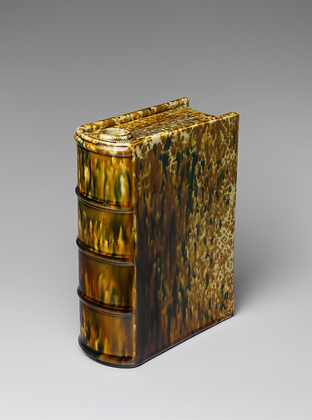


--- #2  (sim=0.2542)  objectID=552 ---
  objectID: 552
  title: Bonnet
  objectName: Bonnet
  department: The American Wing
  culture: American, Shaker
  medium: Palm leaf
  objectDate: 1800–1900
  artistDisplayName: United Society of Believers in Christ’s Second Appearing (“Shakers”)
  creditLine: Gift of Mrs. G. James Fawcett, in memory of John S. Rudd, 1985
  city: New Lebanon
  state: New York
  country: United States
  objectURL: https://www.metmuseum.org/art/collection/search/552


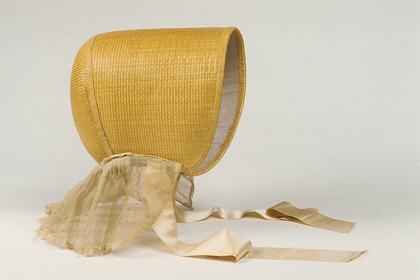


--- #3  (sim=0.2450)  objectID=332 ---
  objectID: 332
  title: Basin
  objectName: Basin
  department: The American Wing
  culture: American
  medium: Earthenware with slip decoration
  objectDate: 1860–1900
  creditLine: Gift of Mrs. Robert W. de Forest, 1933
  city: Strasburg
  state: Virginia
  country: United States
  objectURL: https://www.metmuseum.org/art/collection/search/332


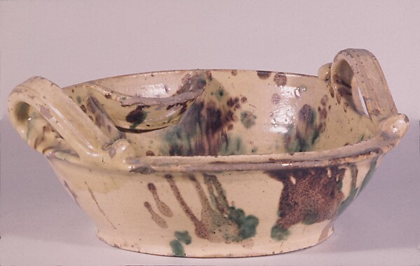


--- #4  (sim=0.2447)  objectID=2849 ---
  objectID: 2849
  title: Cup and Saucer
  objectName: Cup and saucer
  department: The American Wing
  culture: German
  medium: Porcelain
  objectDate: ca. 1844–47
  artistDisplayName: Koenigliche Porzellan Manufaktur
  creditLine: Bequest of Adeline R. Brown, 1947
  city: Berlin
  country: Germany
  objectURL: https://www.metmuseum.org/art/collection/search/2849


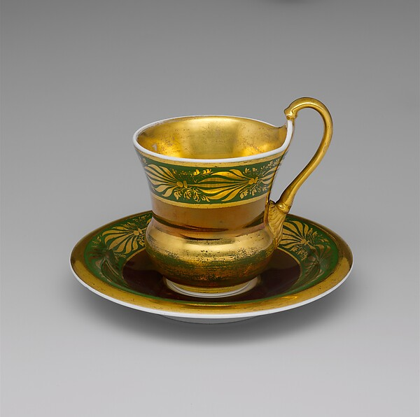


--- #5  (sim=0.2441)  objectID=287 ---
  objectID: 287
  title: Furniture Hardware
  objectName: Furniture hardware
  department: The American Wing
  medium: Gilt brass
  objectDate: 1820–30
  artistDisplayName: Henry Kellam Hancock
  creditLine: Gift of Mrs. Edward Hunting Smith, 1968
  country: France
  objectURL: https://www.metmuseum.org/art/collection/search/287


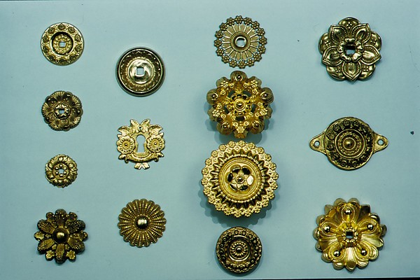

In [31]:
import numpy as np
import torch

QUERY = "gold pastel"

# Text embedding
q_txt = text_model.encode([QUERY], convert_to_numpy=True)[0].astype(np.float64)
q_txt = q_txt / np.linalg.norm(q_txt)

X_txt = np.stack(joined["text_embedding"].values)
X_txt = X_txt / np.linalg.norm(X_txt, axis=1, keepdims=True)
sim_txt = X_txt @ q_txt

idx_txt = np.argsort(-sim_txt)[:5]

print("=== Top 5 by text embedding ===")
for rank, i in enumerate(idx_txt, 1):
    r = joined.iloc[i]
    print(f"{rank}. sim={sim_txt[i]:.4f}  objectID={r['objectID']}  {r.get('title', '')[:80]}")

# image embedding
device = next(clip_model.parameters()).device
inputs = clip_proc(text=[QUERY], return_tensors="pt", padding=True)
inputs = {k: v.to(device) for k, v in inputs.items()}
with torch.no_grad():
    t = clip_model.get_text_features(**inputs)
t = t / t.norm(dim=-1, keepdim=True)
q_clip = t.cpu().numpy().squeeze(0)

clip_rows = []
valid = []
for v in joined["clip_embedding"]:
    a = np.asarray(v, dtype=np.float32)
    ok = np.all(np.isfinite(a)) and a.size > 0
    valid.append(ok)
    clip_rows.append(a if ok else np.zeros_like(q_clip))

X_img = np.stack(clip_rows)
X_img = X_img / (np.linalg.norm(X_img, axis=1, keepdims=True) + 1e-12)
sim_img = X_img @ q_clip
sim_img = np.where(valid, sim_img, -np.inf)

idx_img = np.argsort(-sim_img)[:5]

from IPython.display import display
import sys
from pathlib import Path

import pandas as pd

sys.path.insert(0, str(Path("src").resolve()))
from embed_prep import image_url, load_pil_image

# Columns to show
META_COLS = [
    "objectID",
    "title",
    "objectName",
    "department",
    "classification",
    "culture",
    "period",
    "medium",
    "objectDate",
    "artistDisplayName",
    "creditLine",
    "city",
    "state",
    "country",
    "objectURL",
]


def show_retrieval(title: str, indices, sims) -> None:
    print("\n" + "=" * 72)
    print(title)
    print("=" * 72)
    for rank, i in enumerate(indices, 1):
        r = joined.iloc[i]
        sim = float(sims[i])
        print(f"\n--- #{rank}  (sim={sim:.4f})  objectID={r.get('objectID')} ---")
        for c in META_COLS:
            if c in joined.columns:
                val = r.get(c)
                if pd.notna(val) and str(val).strip() != "":
                    print(f"  {c}: {val}")

        url = image_url(r.to_dict(), prefer="primaryImageSmall")
        if url:
            im = load_pil_image(url, timeout=90)
            if im is not None:
                im = im.copy()
                im.thumbnail((420, 420))
                display(im)
            else:
                print("  [image download failed]")
        else:
            print("  [no image URL]")

show_retrieval(
    "Top 5 by TEXT embedding (sentence-transformers)",
    idx_txt,
    sim_txt,
)

show_retrieval(
    "Top 5 by IMAGE embedding (CLIP text query vs image vectors)",
    idx_img,
    sim_img,
)